In [2]:
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from utils import *
from genData import *
from model.unet import Attention_UNet


# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. No GPU found.")

# Configuration
det = 'H1L1'
f0 = 500
size = (512, 64)
Tsft = 14400
train_level = 22
batch_size = 8

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed4.npz'
val_data = np.load(filename, allow_pickle=True)
targets = val_data['clean_image']
masks = new_mask(normalize(targets))  # Assuming new_mask and normalize are defined in utils

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)
model.eval()

# Function to compute detection statistic
def compute_detection_statistic(images, method='mean_sq'):
    valid_methods = {'mean', 'mean_sq', 'kl_one', 'kl_random'}
    if method not in valid_methods:
        raise ValueError(f"Method must be one of {valid_methods}, got {method}")
    
    images_np = np.abs(images)
    if method == 'mean_sq':
        return np.mean(np.square(images_np.transpose(0, 2, 3, 1)), axis=(1, 2, 3))

GPU Name: Tesla V100-PCIE-16GB


In [3]:
# Initialize lists for depth and pdet
depth = []
pdet = []
max_train_levels = [5*i for i in range(1, 7)]  
def load_dataset(images, batch_size=8, shuffle=True):

    # Convert to torch tensors
    images_tensor = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
    dataset = TensorDataset(images_tensor)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return data_loader


# Compute pdet
noise_data = np.empty((1000,) + size + (4,))
for i in range(noise_data.shape[0]):
    noise_data[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
noise_data = normalize(noise_data)
noise_loader = load_dataset(noise_data, batch_size=batch_size, shuffle=False)

noise_predictions = []
with torch.no_grad():
    for batch in tqdm(noise_loader, desc="Processing noise"):
        images = batch[0].to(device)
        outputs = model(images)
        noise_predictions.append(outputs.cpu().numpy())
noise_predictions = np.concatenate(noise_predictions, axis=0)
noise_stats = compute_detection_statistic(noise_predictions, method='mean_sq')

    
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    data = normalize(noise + targets)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth.append(Sn)
    pdet.append(pdet_value)

# Convert to numpy arrays
depth = np.array(depth)
pdet = np.array(pdet)

Processing Sn=30: 100%|██████████| 125/125 [00:05<00:00, 23.08it/s]


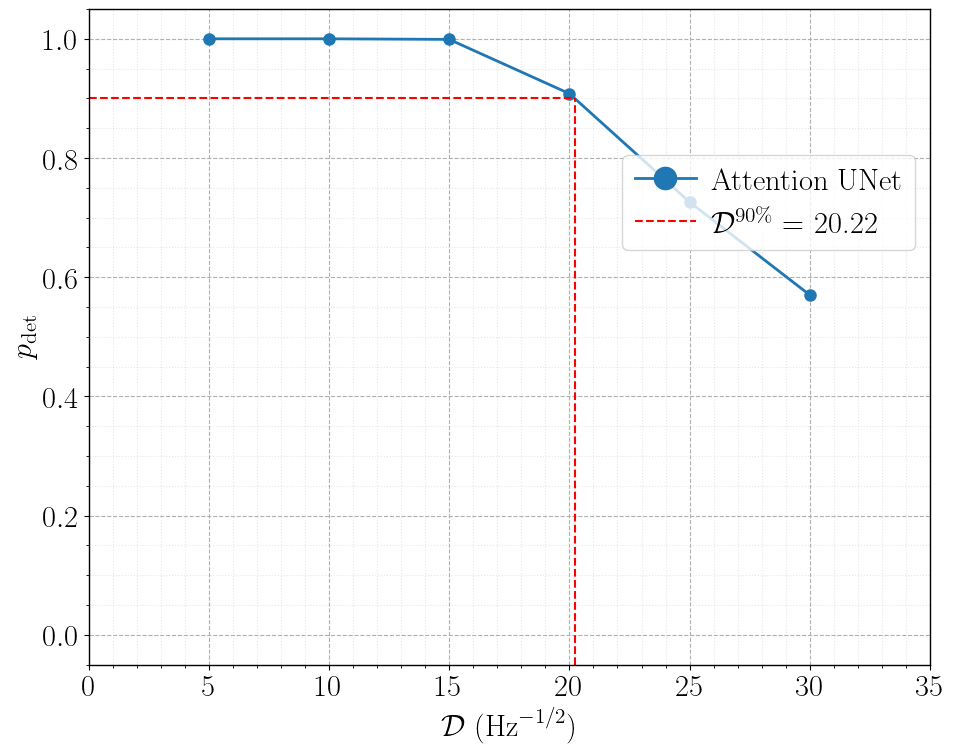

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Matplotlib configuration
plt.rcParams.update({
    'text.usetex': True,
    'axes.linewidth': 1,
    'axes.grid': False,
    'axes.labelweight': 'normal',
    'font.family': 'DejaVu Sans',
    'font.size': 22,
    'mathtext.fontset': 'cm'
})

            
# Create figure and axis
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # Use tab10 colormap for distinct colors

fig, ax = plt.subplots(figsize=(10, 8))

# Plot Weave data as a line
#ax.plot(depth_mf[:-2], pdet_mf[:-2], color='k', label='Weave', lw=2)
sort_idx = np.argsort(depth)
depth_sorted = depth[sort_idx]
pdet_sorted = pdet[sort_idx]
p90 = 0.9
d90 = np.interp(p90, pdet_sorted[::-1], depth_sorted[::-1])  # Reverse to handle decreasing pdet

# Plot Attention UNet data with line and markers
ax.plot(depth, pdet, color=colors[0], linestyle='-', lw=2, marker='o', markersize=8, label='Attention UNet')

# Add horizontal and vertical lines at pdet = 0.9 and interpolated depth
ax.plot([0, d90], [p90, p90], color='red', linestyle='--', lw=1.5)
ax.plot([d90, d90], [-0.05, p90], color='red', linestyle='--', lw=1.5, 
        label=r'$\mathcal{D}^{90\%}=$' + f' {d90:.2f}')

# Axis labels and styling
ax.set_xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$')
ax.set_ylabel(r'$p_{\mathrm{det}}$')
ax.legend(fontsize=22, loc='upper right', markerscale=2, handlelength=2, handletextpad=0.5, bbox_to_anchor=(1, 0.8))
ax.grid(True, which='major', linestyle='dashed')
ax.set_xlim(0, 35)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

# Save figure
plt.tight_layout()
#plt.savefig(f'../result/plots/pdet_with_error_bars.pdf', dpi=300, bbox_inches='tight')

In [5]:
max_train_levels = [19.5, 19.8, 20.2]

depth_ex = []
pdet_ex = []
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    data = normalize(noise + targets)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth_ex.append(Sn)
    pdet_ex.append(pdet_value)

# Convert to numpy arrays
depth_ex = np.array(depth_ex)
pdet_ex = np.array(pdet_ex)

Processing Sn=20.2: 100%|██████████| 125/125 [00:05<00:00, 24.36it/s]


In [6]:
depth_ex, pdet_ex

(array([19.5, 19.8, 20.2]), array([0.919, 0.922, 0.901]))

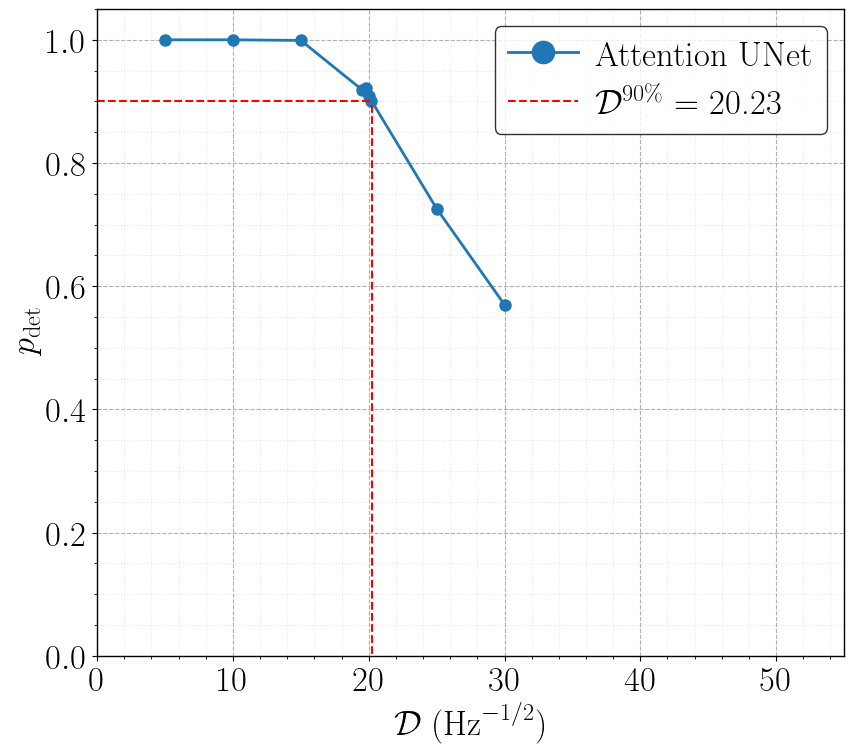

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Matplotlib configuration
plt.rcParams.update({
    'text.usetex': True,
    'axes.linewidth': 1,
    'axes.grid': False,
    'axes.labelweight': 'normal',
    'font.family': 'DejaVu Sans',
    'font.size': 22,
    'mathtext.fontset': 'cm'
})

# Insert depth_ex and pdet_ex into depth and pdet to maintain ascending order
# Combine all points
combined = np.vstack((np.column_stack((depth, pdet)), np.column_stack((depth_ex, pdet_ex))))
# Sort by depth (first column)
sorted_indices = np.argsort(combined[:, 0])
depth_combined = combined[sorted_indices, 0]
pdet_combined = combined[sorted_indices, 1]

# Use only the first len(depth)-4 points from combined data (to match depth[:-4])
n_points = len(depth_combined)
depth_plot = depth_combined[:n_points]
pdet_plot = pdet_combined[:n_points]

# Interpolate depth at pdet = 0.9
# Sort by depth for interpolation (already sorted, but confirm)
sort_idx = np.argsort(depth_plot)
depth_sorted = depth_plot[sort_idx]
pdet_sorted = pdet_plot[sort_idx]

# Linear interpolation (reverse pdet to handle decreasing trend)
p90 = 0.9
d90 = np.interp(p90, pdet_sorted[::-1], depth_sorted[::-1])

# Create figure and axis
fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Plot combined Attention UNet data with line and markers
ax.plot(depth_plot, pdet_plot, color=colors[0], linestyle='-', lw=2, marker='o', markersize=8, label='Attention UNet')

# Add horizontal and vertical lines at pdet = 0.9 and interpolated depth
ax.plot([0, d90], [p90, p90], color='red', linestyle='--', lw=1.5)
ax.plot([d90, d90], [-0.05, p90], color='red', linestyle='--', lw=1.5, 
        label=r'$\mathcal{D}^{90\%}=$' + f' {d90:.2f}')

# Axis labels and styling
ax.set_xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$', fontsize=25)
ax.set_ylabel(r'$p_{\mathrm{det}}$', fontsize=25)
ax.legend(fontsize=25, loc=1, markerscale=2, handlelength=2, handletextpad=0.5, edgecolor='k')
ax.grid(True, which='major', linestyle='dashed')
ax.set_xlim(0, 55)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='both', which='major', labelsize=25)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

# Save figure
plt.tight_layout()
#plt.savefig('../result/plots/pdet_20Hz.pdf', dpi=300, bbox_inches='tight')

In [8]:
max_train_levels = [36.77]

depth_ex = []
pdet_ex = []
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    data = normalize(noise + targets)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth_ex.append(Sn)
    pdet_ex.append(pdet_value)

# Convert to numpy arrays
depth_ex = np.array(depth_ex)
pdet_ex = np.array(pdet_ex)

Processing Sn=36.77: 100%|██████████| 125/125 [00:05<00:00, 23.12it/s]


In [9]:
depth_ex, pdet_ex

(array([36.77]), array([0.415]))